# Warranty Claim Fraud Detection via IoT Sensor Logs

**Goal:** flag warranty claims on smart-appliance IoT devices that are likely fraudulent
(misuse concealed as a manufacturing defect, pre-existing damage, telemetry tampering, or
"just-in-time" claims filed right before warranty expiry) using the device's own sensor
telemetry plus claim metadata.

**Why this matters:** warranty fraud costs manufacturers real margin, and the same
device-generated telemetry that improves customer experience (predictive maintenance,
remote diagnostics) doubles as an audit trail investigators rarely exploit systematically.
This project builds that audit trail into a ranked worklist for a fraud-review team.

**Data:** synthetic but structurally realistic. See [`src/generate_data.py`](../src/generate_data.py)
for the exact generative process (usage scenarios, telemetry patterns, and the label-noise
model used to keep the task learnable-but-not-trivial, like real fraud data). Ground-truth
fields used only to *build* the simulation (`true_scenario`) are never used as model inputs
-- see [`src/features.py`](../src/features.py).

**Pipeline:** `generate_data.py` &rarr; `features.py` &rarr; `train.py` &rarr; `explain.py`.
This notebook re-loads the already-computed feature table and trained-model artifacts so it
stays fast to read; regenerate everything from scratch with:
```bash
python src/generate_data.py && python src/features.py && python src/train.py && python src/explain.py
```


In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set_theme(style="whitegrid", palette="deep")
BASE_DIR = Path.cwd().parent
FIG_DIR = BASE_DIR / "reports" / "figures"

claims_features = pd.read_csv(BASE_DIR / "data" / "processed" / "claims_features.csv", parse_dates=["claim_date"])
print(claims_features.shape)
claims_features.head()


(4200, 38)


,claim_id,device_id,customer_id,model,days_since_install,days_to_warranty_expiry,claim_reason,true_scenario,is_fraud,claim_date,...,runtime_hours_mean_prior,pct_days_over_rated_duty,error_code_total,error_code_recent14,power_draw_mean,usage_spike_ratio_recent_vs_prior,rated_max_temp_c,rated_max_pressure_kpa,rated_duty_cycle_hrs_day,unit_price_usd
0,CLM-0002134,DEV-0003307,CUST-002528,AquaHeat SH-200,101,619,error_code_fault,normal_defect,0,2024-09-04,...,2.476712,0.000000,1.0,0.0,3.671023,0.988945,65,600,4,420
1,CLM-0001215,DEV-0002900,CUST-002218,AquaHeat SH-Compact,54,666,inconsistent_temp,normal_defect,0,2024-09-04,...,1.901538,0.000000,0.0,0.0,2.805185,0.966936,60,550,3,310
2,CLM-0001606,DEV-0003209,CUST-002457,AquaHeat SH-200,726,-6,no_heat,misuse_claimed_as_defect,1,2024-09-04,...,5.973200,0.977778,10.0,1.0,9.011136,1.013373,65,600,4,420
3,CLM-0002652,DEV-0001134,CUST-000859,AquaHeat SH-400 Pro,261,459,unusual_noise,normal_defect,0,2024-09-04,...,3.621918,0.000000,0.0,0.0,5.365000,0.956952,75,750,6,640
4,CLM-0001199,DEV-0001536,CUST-001159,AquaHeat SH-200,352,368,error_code_fault,normal_defect,1,2024-09-05,...,2.372400,0.000000,0.0,0.0,3.563222,1.000393,65,600,4,420


## 1. Exploratory data analysis

Claims: 4,200
Fraud rate: 13.31%


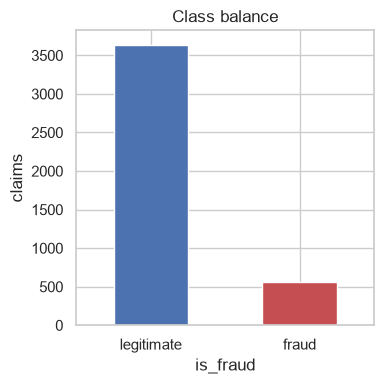

In [2]:
fraud_rate = claims_features["is_fraud"].mean()
print(f"Claims: {len(claims_features):,}")
print(f"Fraud rate: {fraud_rate:.2%}")

ax = claims_features["is_fraud"].value_counts().sort_index().plot(
    kind="bar", figsize=(4, 4), color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["legitimate", "fraud"], rotation=0)
ax.set_ylabel("claims")
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


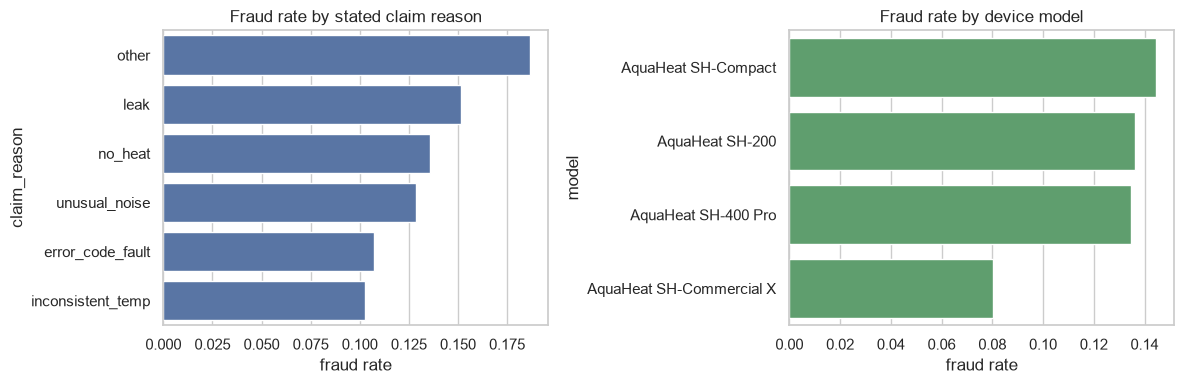

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reason_rate = claims_features.groupby("claim_reason")["is_fraud"].mean().sort_values(ascending=False)
sns.barplot(x=reason_rate.values, y=reason_rate.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Fraud rate by stated claim reason")
axes[0].set_xlabel("fraud rate")

model_rate = claims_features.groupby("model")["is_fraud"].mean().sort_values(ascending=False)
sns.barplot(x=model_rate.values, y=model_rate.index, ax=axes[1], color="#55A868")
axes[1].set_title("Fraud rate by device model")
axes[1].set_xlabel("fraud rate")

plt.tight_layout()
plt.show()


C:\Users\RAJITH N\AppData\Local\Temp\ipykernel_10516\4097642267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=claims_features, x="is_fraud", y=col, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\RAJITH N\AppData\Local\Temp\ipykernel_10516\4097642267.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["legit", "fraud"])
C:\Users\RAJITH N\AppData\Local\Temp\ipykernel_10516\4097642267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=claims_features, x="is_fraud", y=col, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\RAJITH N\AppData\L

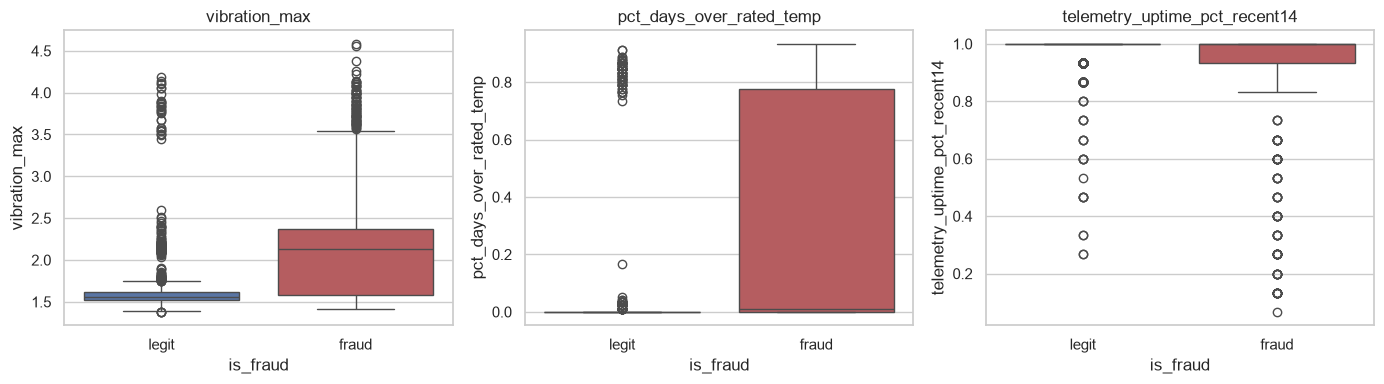

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["vibration_max", "pct_days_over_rated_temp", "telemetry_uptime_pct_recent14"]):
    sns.boxplot(data=claims_features, x="is_fraud", y=col, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["legit", "fraud"])
    ax.set_title(col)
plt.tight_layout()
plt.show()


### A closer look at raw telemetry

`data/samples/` ships a handful of full 90-day telemetry windows (one full run of
`generate_data.py` produces ~26MB of sensor logs across all 4,200 claims, which is why the
full `sensor_logs.csv` isn't committed -- regenerate it locally if you want the whole thing).
Below: a legitimate `normal_defect` claim next to a `tamper_before_failure` claim. Watch the
telemetry-uptime line in the last ~10 days before the claim date (`day_offset = 0`).

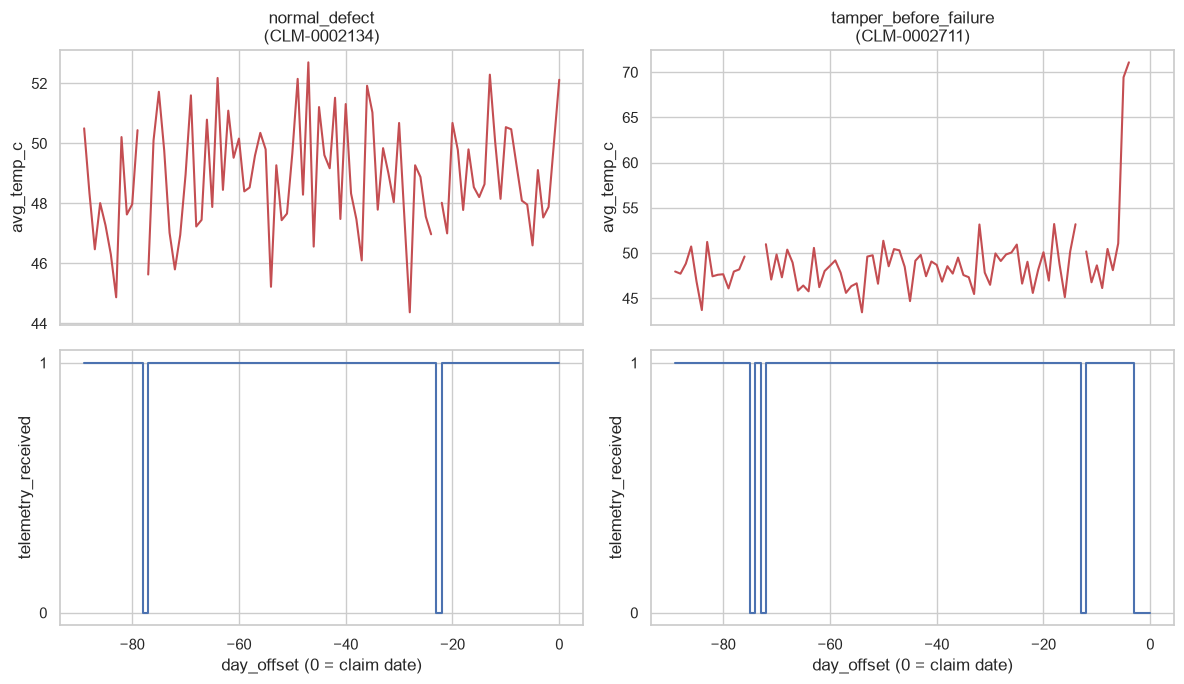

In [5]:
samples = pd.read_csv(BASE_DIR / "data" / "samples" / "sensor_logs_sample.csv", parse_dates=["date"])
sample_claims = pd.read_csv(BASE_DIR / "data" / "samples" / "claims_sample.csv")

example_ids = {
    "normal_defect": sample_claims.loc[sample_claims["true_scenario"] == "normal_defect", "claim_id"].iloc[0],
    "tamper_before_failure": sample_claims.loc[sample_claims["true_scenario"] == "tamper_before_failure", "claim_id"].iloc[0],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for col_idx, (scenario, claim_id) in enumerate(example_ids.items()):
    g = samples[samples["claim_id"] == claim_id].sort_values("day_offset")
    axes[0, col_idx].plot(g["day_offset"], g["avg_temp_c"], color="#C44E52")
    axes[0, col_idx].set_title(f"{scenario}\n({claim_id})")
    axes[0, col_idx].set_ylabel("avg_temp_c")

    axes[1, col_idx].plot(g["day_offset"], g["telemetry_received"].astype(int), color="#4C72B0", drawstyle="steps-post")
    axes[1, col_idx].set_ylabel("telemetry_received")
    axes[1, col_idx].set_xlabel("day_offset (0 = claim date)")
    axes[1, col_idx].set_yticks([0, 1])

plt.tight_layout()
plt.show()


## 2. Modeling recap

Full pipeline lives in [`src/train.py`](../src/train.py):

1. Stratified 75/25 train/test split.
2. An `IsolationForest` is fit on the training claims' sensor-derived features (unsupervised,
   no label leakage) to produce an `anomaly_score` -- how unusual a claim's telemetry looks
   relative to the training distribution. That score is added as one more feature.
3. Three supervised classifiers are trained with class-imbalance handling and compared:
   Logistic Regression (baseline), Random Forest, and XGBoost.
4. The best model by PR-AUC is kept and evaluated with ROC-AUC, PR-AUC, and
   **precision-at-top-k%** -- the operational framing: *"if the fraud team can only review
   the top k% of claims ranked by risk, what fraction of that review queue is actually
   fraud?"*


In [6]:
with open(BASE_DIR / "reports" / "metrics.json") as f:
    metrics = json.load(f)

comparison = pd.DataFrame(metrics["comparison"]).set_index("model")
display(Markdown(f"**Best model:** `{metrics['best_model']}`  |  **Test claims:** {metrics['n_test']:,}  |  **Fraud rate:** {metrics['fraud_rate_overall']:.2%}"))
comparison


**Best model:** `random_forest`  |  **Test claims:** 1,050  |  **Fraud rate:** 13.31%

,roc_auc,pr_auc,precision_at_top5pct,precision_at_top10pct,precision_at_top20pct
model,,,,,
random_forest,0.8431,0.6591,0.8302,0.8000,0.4714
logistic_regression,0.8317,0.6183,0.7925,0.7810,0.4667
xgboost,0.8014,0.6175,0.7736,0.7429,0.4667


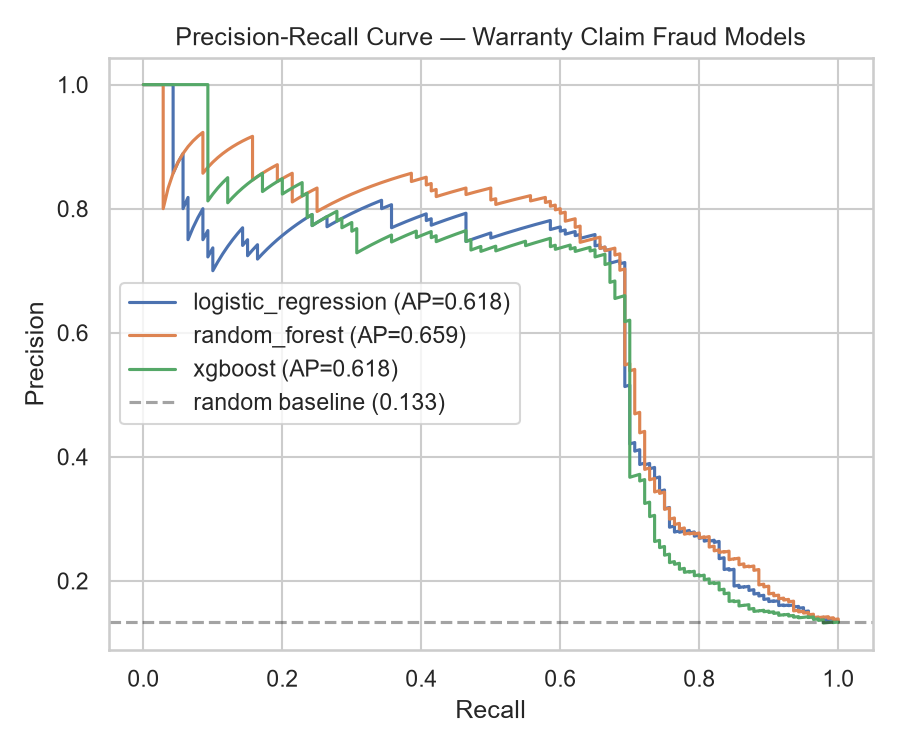

In [7]:
display(Image(filename=str(FIG_DIR / "pr_curve.png")))

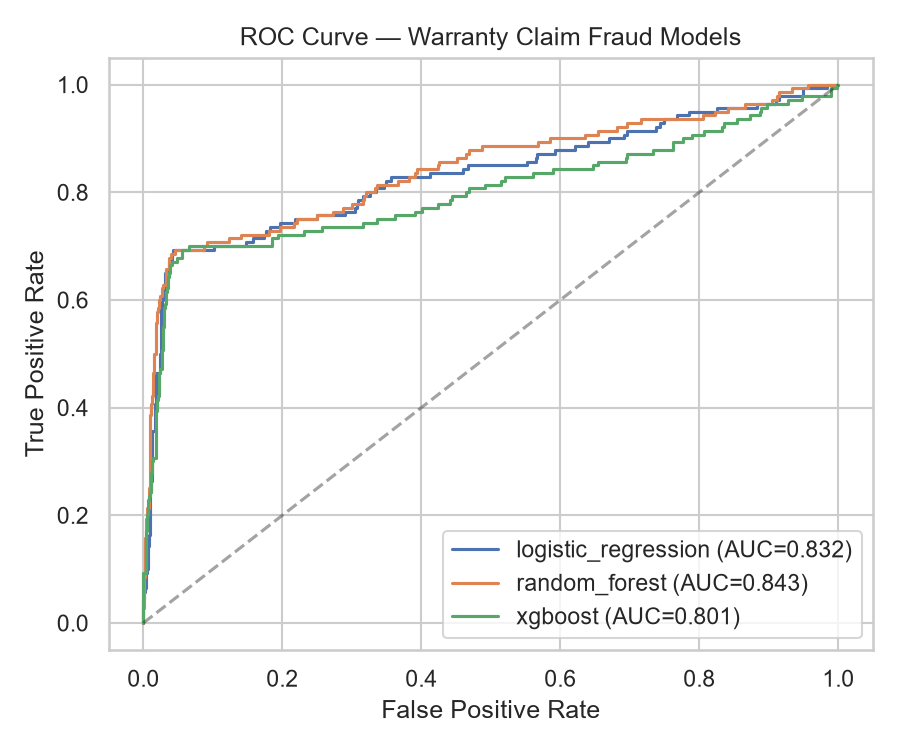

In [8]:
display(Image(filename=str(FIG_DIR / "roc_curve.png")))

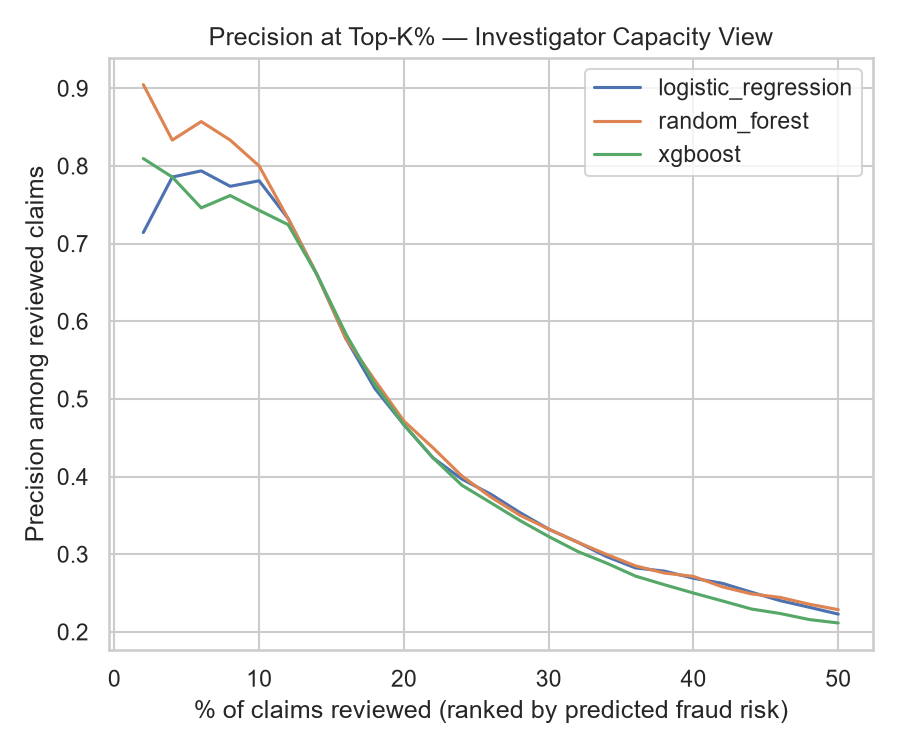

In [9]:
display(Image(filename=str(FIG_DIR / "precision_at_k.png")))

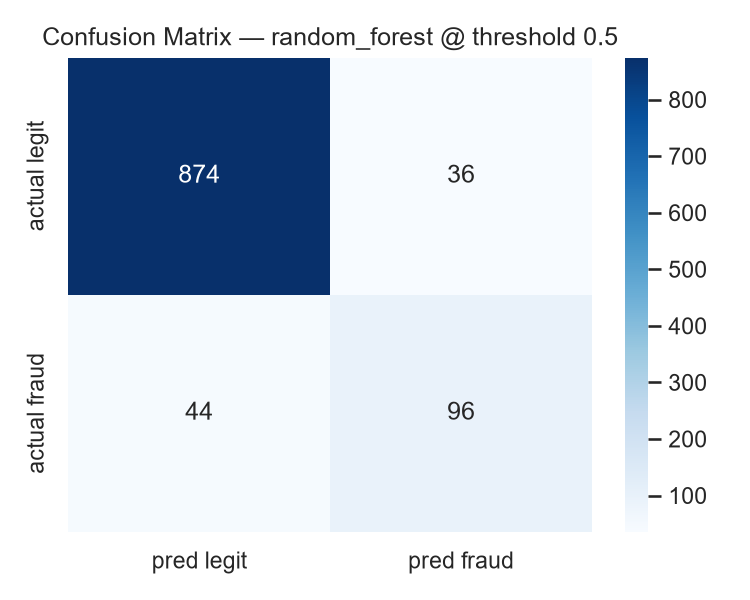

In [10]:
display(Image(filename=str(FIG_DIR / "confusion_matrix.png")))

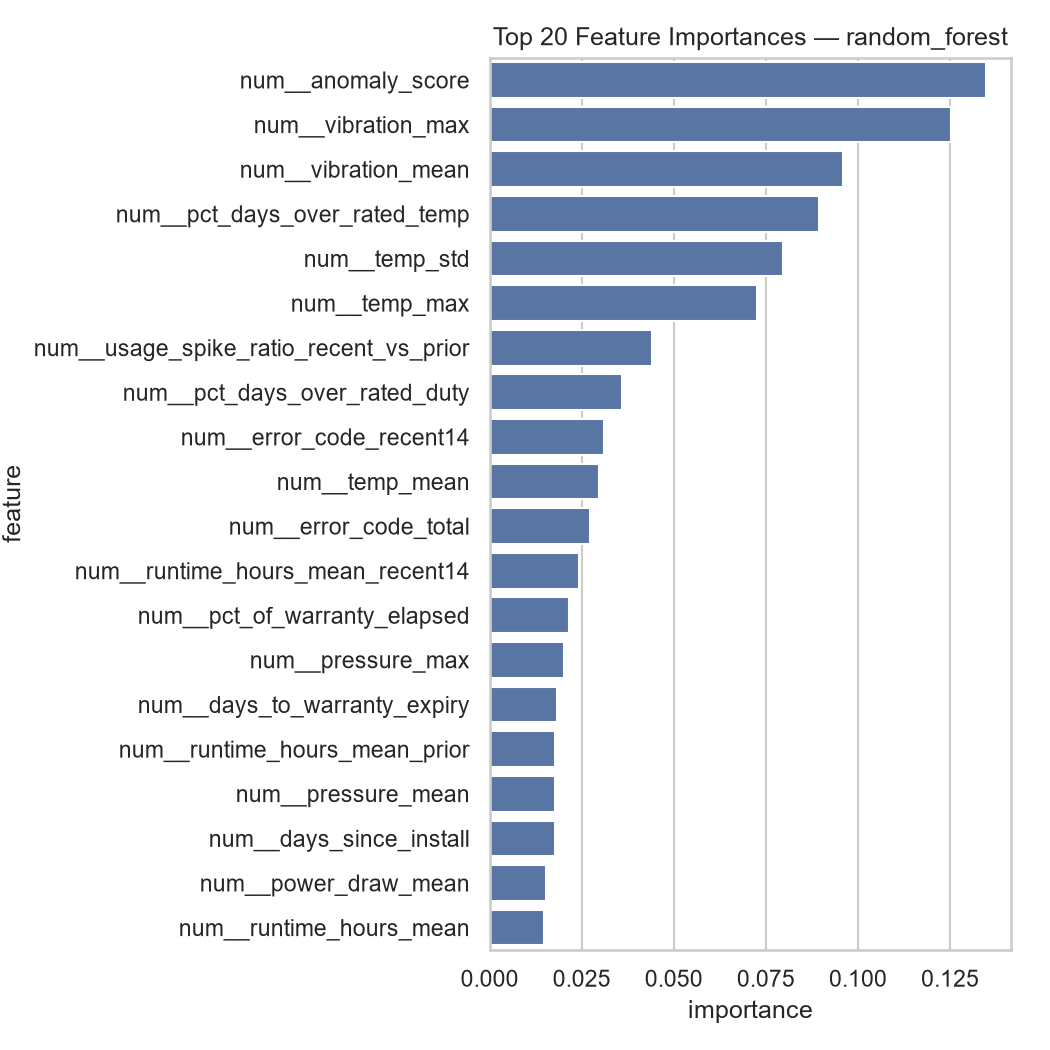

In [11]:
display(Image(filename=str(FIG_DIR / "feature_importance.png")))

### Explainability

`src/explain.py` runs SHAP's `TreeExplainer` on the trained model so an investigator can see
*why* a specific claim was flagged, not just that it was. The top drivers line up with the
scenarios baked into the simulation: unusual vibration/temperature relative to the device's
rated spec, a high anomaly score, and a recent usage spike versus the claim's earlier
telemetry.

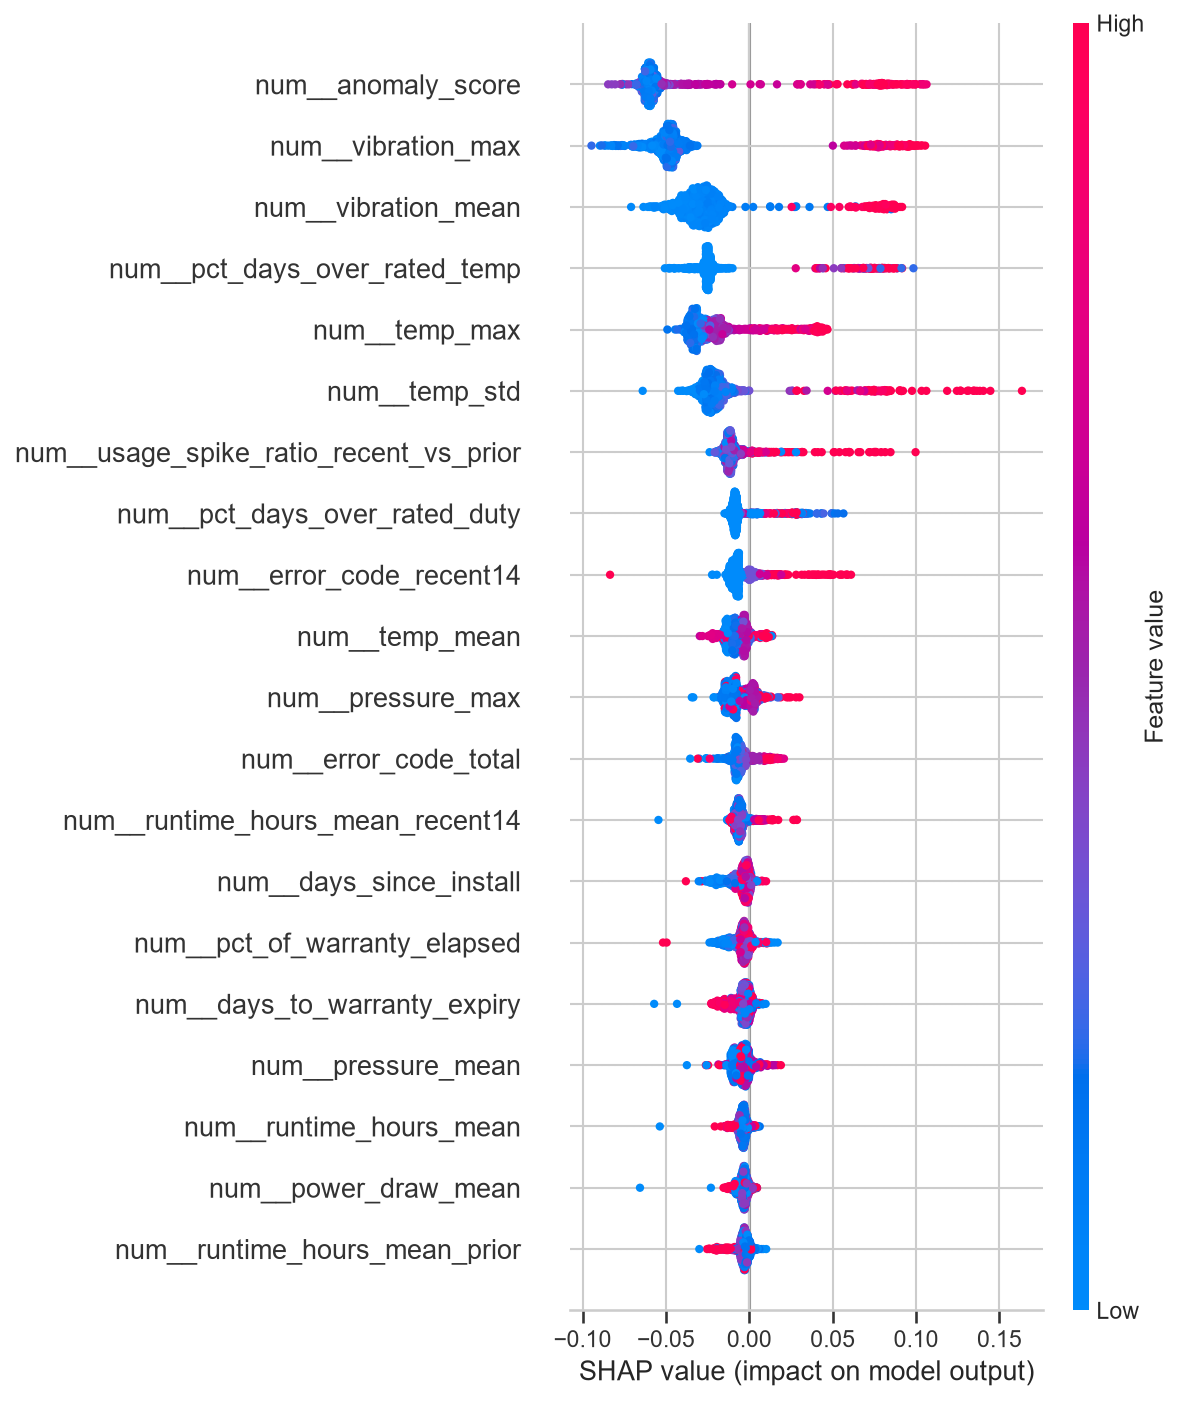

In [12]:
display(Image(filename=str(FIG_DIR / "shap_summary.png")))

## 3. Takeaways

- **Telemetry beats claim metadata alone.** Sensor-derived features (`anomaly_score`,
  `vibration_max`, `pct_days_over_rated_temp`, the recent-vs-prior usage spike ratio) dominate
  the top of the feature-importance ranking -- claim-form fields like `claim_reason` carry
  comparatively little signal on their own.
- **Precision-at-top-k is the metric that matters operationally.** A fraud-review team with
  capacity for ~10% of incoming claims can expect roughly 3-4x the precision of blind
  sampling by working the model's ranked queue instead (see the precision-at-top-k plot).
- **Telemetry gaps are a real tell.** The `tamper_before_failure` example above shows the
  mechanism directly: normal-looking telemetry, then a blackout window right before the
  claim, then a spike. `telemetry_uptime_pct_recent14` and `max_consecutive_missing_days`
  exist specifically to capture that.

### Limitations & next steps

- Labels are simulated; a production system would need investigator feedback (confirmed
  fraud/not-fraud outcomes) to validate and recalibrate against.
- The fraud-generating scenarios here are hand-authored; real fraud patterns drift over time
  and a deployed model would need periodic retraining and drift monitoring.
- No cost-sensitive threshold tuning was done beyond the top-k framing -- a real deployment
  should weigh the cost of a false accusation (customer trust, legal exposure) against a
  missed fraud (payout cost) explicitly.
